# Práctica 3 - Exploración de un dataset con pandas

## Objetivos

En esta práctica trabajarás con un dataset de clientes utilizando Python.

Al finalizar deberás ser capaz de:

- cargar datos desde un archivo CSV
- trabajar con un `DataFrame` de pandas
- identificar muestras y variables
- consultar la estructura de un dataset
- calcular estadísticas descriptivas
- seleccionar y filtrar datos
- analizar variables categóricas
- crear visualizaciones sencillas
- identificar las características \(X\) y la variable objetivo \(y\)
- determinar qué tipo de problema de Machine Learning podría resolverse

> **Importante:** no debes entrenar ningún modelo de Machine Learning en esta práctica.

## Contexto

Una empresa de telecomunicaciones quiere analizar el comportamiento de sus clientes. Dispone de información histórica y conoce qué clientes terminaron abandonando el servicio.

El objetivo futuro será desarrollar un sistema capaz de predecir:

> **¿Qué clientes tienen riesgo de abandonar la compañía?**

Para realizar la práctica utilizaremos el archivo `clientes.csv`.

| Variable | Descripción |
|---|---|
| `cliente_id` | Identificador del cliente |
| `edad` | Edad del cliente |
| `antiguedad` | Meses como cliente |
| `cuota_mensual` | Cuota mensual en euros |
| `consumo_datos` | Consumo mensual de datos en GB |
| `llamadas_soporte` | Número de llamadas a soporte |
| `incidencias` | Número de incidencias registradas |
| `tipo_contrato` | Mensual, anual o bienal |
| `satisfaccion` | Valoración del servicio de 1 a 5 |
| `abandono` | Indica si el cliente abandonó: Sí/No |

Cada fila corresponde a un cliente.

### Instrucciones

Completa las celdas de código marcadas con `# TODO`.

Cuando se solicite una interpretación, escribe tu respuesta en la celda Markdown correspondiente. No basta con ejecutar código: debes **interpretar los resultados**.

## Parte 1 - Preparación del entorno

### Ejercicio 1 - Importación

Importa NumPy, pandas y Matplotlib utilizando los alias convencionales.

In [29]:
# TODO: importa NumPy, pandas y matplotlib.pyplot
import numpy as np #arrays, operaciones con números
import pandas as pd #DataFrames, manipulación de datos
import matplotlib.pyplot as plt #gráficos

### Respuesta

- **NumPy:** nos sirve para trabajar con arrays y realizar operaciones numéricas de forma eficiente.
- **pandas:** lo utilizaremos para cargar y manipular el dataset en un DataFrame, filtrar filas, seleccionar columnas y analizar datos tabulares.
- **Matplotlib:** lo usaremos para crear gráficos sencillos como histogramas y diagramas de dispersión que ayuden a visualizar patrones en los datos.


## Parte 2 - Carga e inspección inicial

### Ejercicio 2 - Cargar el dataset

Carga `clientes.csv` en un DataFrame denominado `df` y muestra sus primeras filas.

In [30]:
# TODO: carga el archivo clientes.csv en df
df = pd.read_csv('clientes.csv')

# TODO: muestra las primeras filas
df.head()

,cliente_id,edad,antiguedad,cuota_mensual,consumo_datos,llamadas_soporte,incidencias,tipo_contrato,satisfaccion,abandono
0,10001,23,61.0,32.16,11.9,1,2,Mensual,1,No
1,10002,62,79.0,45.71,17.4,2,0,Anual,2,No
2,10003,55,49.0,60.48,14.6,0,1,Mensual,5,No
3,10004,43,6.0,116.82,21.8,4,0,Anual,3,No
4,10005,43,70.0,36.13,8.8,2,2,Anual,1,Sí


### Respuesta

**¿Qué representa cada fila del DataFrame?**

Cada fila es una muestra 

**¿Qué representa cada columna?**

Y cada columna es una variable de la muestra.

### Ejercicio 3 - Dimensiones

Obtén mediante código las dimensiones del dataset.

In [31]:
# TODO: muestra las dimensiones del DataFrame
df.shape

(180, 10)

### Respuesta

- **Número de muestras:** 180
- **Número de variables:** 10

### Ejercicio 4 - Columnas

Obtén mediante código los nombres de todas las columnas.

In [32]:
# TODO: muestra los nombres de las columnas
df.columns

Index(['cliente_id', 'edad', 'antiguedad', 'cuota_mensual', 'consumo_datos',
       'llamadas_soporte', 'incidencias', 'tipo_contrato', 'satisfaccion',
       'abandono'],
      dtype='str')

### Respuesta

**¿Qué columna parece representar la variable que queremos predecir? ¿Por qué?**

La columna 'abandono' es la que queremos predecir, ya que es lo que quiero que mi agente anticipe y mejore.

### Ejercicio 5 - Tipos de datos

Obtén los tipos de datos de todas las columnas.

In [33]:
# TODO: consulta los tipos de datos
df.dtypes

cliente_id            int64
edad                  int64
antiguedad          float64
cuota_mensual       float64
consumo_datos       float64
llamadas_soporte      int64
incidencias           int64
tipo_contrato           str
satisfaccion          int64
abandono                str
dtype: object

### Respuesta

**Variables numéricas:**
Las que tienen int y float

**Variables categóricas:**
Las que tienen str

**¿`cliente_id` debería considerarse una característica numérica simplemente porque contiene números? Razona la respuesta.**

No se consideraría una caracterísitca numérica porque es un identificador de cada cliente. En este caso, sería una característica categórica.

## Parte 3 - Estructura y calidad inicial

### Ejercicio 6 - Información general

Utiliza `info()` para analizar la estructura del dataset.

In [34]:
# TODO: muestra la información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cliente_id        180 non-null    int64  
 1   edad              180 non-null    int64  
 2   antiguedad        178 non-null    float64
 3   cuota_mensual     180 non-null    float64
 4   consumo_datos     179 non-null    float64
 5   llamadas_soporte  180 non-null    int64  
 6   incidencias       180 non-null    int64  
 7   tipo_contrato     180 non-null    str    
 8   satisfaccion      180 non-null    int64  
 9   abandono          180 non-null    str    
dtypes: float64(3), int64(5), str(2)
memory usage: 14.2 KB


### Respuesta

- **¿Cuántas entradas contiene?** 180, con índices desde 0 hasta 179.
- **¿Qué tipos de datos aparecen?** En el dataset aparecen columnas de tipo `float64` (3), `int64` (5) y `object`/`string` (2).
- **¿Todas las columnas contienen el mismo número de valores no nulos?** No. No todas las columnas tienen 180 valores no nulos, lo que indica que algunas tienen datos faltantes.
- **¿Parece existir algún valor ausente?** Sí. La diferencia entre el número total de filas y el recuento de valores no nulos en algunas columnas sugiere la presencia de valores ausentes.
- **¿Cómo puedes deducirlo a partir de `info()`?** `info()` muestra, para cada columna, el número de valores no nulos (`Non-Null Count`). Si ese número es menor que el total de filas (180), significa que hay entradas vacías o nulas en esa columna. Por tanto, al comparar el recuento con el tamaño del DataFrame, se puede detectar la presencia de datos faltantes.

## Parte 4 - Estadística descriptiva

### Ejercicio 7 - Descripción estadística

Obtén las estadísticas descriptivas de las variables numéricas.

In [35]:
# TODO: genera las estadísticas descriptivas
df.describe()

,cliente_id,edad,antiguedad,cuota_mensual,consumo_datos,llamadas_soporte,incidencias,satisfaccion
count,180.000000,180.000000,178.000000,180.000000,179.000000,180.000000,180.000000,180.000000
mean,10090.500000,47.283333,62.050562,71.185667,16.408380,1.705556,1.111111,3.016667
std,52.105662,15.929059,33.991071,29.279251,9.813719,1.249345,1.082563,1.423957
min,10001.000000,18.000000,1.000000,20.480000,1.200000,0.000000,0.000000,1.000000
25%,10045.750000,34.000000,34.000000,43.172500,9.800000,1.000000,0.000000,2.000000
50%,10090.500000,47.000000,61.000000,72.690000,14.300000,1.000000,1.000000,3.000000
75%,10135.250000,62.000000,91.750000,97.177500,20.400000,2.250000,2.000000,4.000000
max,10180.000000,75.000000,120.000000,119.440000,54.200000,6.000000,5.000000,5.000000


### Interpretación

A partir del resultado, indica:

- edad media; 47.2833333 ('mean' indica la edad media)
- edad mínima; 18 ('min' indica la edad mínima)
- edad máxima; 75 ('max' indica la edad máxima)
- cuota mensual media; 71.185667 
- cuota mensual máxima; 119.440000
- media de llamadas a soporte; 1.705556
- media de incidencias; 1.111111
- satisfacción media. 3.016667

La muestra tiene una edad media de 47.28 años, con clientes desde 18 hasta 75 años. La cuota mensual media es de 71.19, y el gasto máximo llega a 119.44, indicando cierta variabilidad en el valor de la cuota. En promedio, cada cliente realiza 1.71 llamadas de soporte y tiene 1.11 incidencias, por lo que los problemas son relativamente bajos. La satisfacción media es 3.02, lo que sugiere una valoración algo baja o cercana a la neutralidad.

### Ejercicio 8 - Cálculos individuales

Calcula mediante instrucciones independientes los valores solicitados.

In [36]:
# TODO: media de edad
print (f"Media de edad: {df['edad'].mean()}")

# TODO: mediana de edad
print (f"Mediana de edad: {df['edad'].median()}")

# TODO: cuota mínima
print (f"Cuota mínima: {df['cuota_mensual'].min()}")

# TODO: cuota máxima
print (f"Cuota máxima: {df['cuota_mensual'].max()}")

# TODO: número total de incidencias
print (f"Número total de incidencias: {df['incidencias'].sum()}")

# TODO: satisfacción media
print (f"Satisfacción media: {df['satisfaccion'].mean()}")

Media de edad: 47.28333333333333
Mediana de edad: 47.0
Cuota mínima: 20.48
Cuota máxima: 119.44
Número total de incidencias: 200
Satisfacción media: 3.0166666666666666


### Comprobación

¿Coinciden estos resultados con los obtenidos mediante `describe()` cuando corresponde?

Sí coinciden sin ningún error.

## Parte 5 - Selección de información

### Ejercicio 9 - Selección de columnas

Crea un DataFrame `df_clientes` que contenga únicamente `edad`, `antiguedad`, `cuota_mensual`, `satisfaccion` y `abandono`. Muestra sus primeras cinco filas.

In [37]:
# TODO: crea df_clientes
# Creo un fitro con las columnas que me interesan y creo un nuevo DataFrame con ellas.
filtro = ['edad', 'antiguedad', 'cuota_mensual', 'satisfaccion', 'abandono']
df_clientes = df[filtro]


# TODO: muestra las primeras cinco filas
df_clientes.head()

,edad,antiguedad,cuota_mensual,satisfaccion,abandono
0,23,61.0,32.16,1,No
1,62,79.0,45.71,2,No
2,55,49.0,60.48,5,No
3,43,6.0,116.82,3,No
4,43,70.0,36.13,1,Sí


### Respuesta

**¿Sigue representando cada fila al mismo cliente que en el DataFrame original? Explica por qué.**

Sí, cada fila sigue representando al mismo cliente que en el DataFrame original, porque se ha realizado una selección de columnas del mismo DataFrame, no una reorganización ni un cambio de orden de las filas. Se conservan exactamente los mismos registros y el mismo índice, solo se eliminan columnas que no son necesarias.

## Parte 6 - Filtrado

### Ejercicio 10 - Clientes por edad

Obtén todos los clientes mayores de 50 años y calcula cuántos cumplen la condición.

In [38]:
# TODO: filtra los clientes mayores de 50 años
df_clientes_filtrado = df_clientes[df_clientes['edad'] > 50]
print(df_clientes_filtrado)

# TODO: calcula cuántos son
print("Mayores de 50 años:",len(df_clientes_filtrado))


     edad  antiguedad  cuota_mensual  satisfaccion abandono
1      62        79.0          45.71             2       No
2      55        49.0          60.48             5       No
5      67         3.0         105.63             2       No
7      58       101.0          53.70             4       No
11     74        27.0          61.04             1       Sí
..    ...         ...            ...           ...      ...
172    62        96.0          35.35             3       Sí
173    59        65.0         104.90             2       No
174    58        66.0          95.67             4       No
176    59       119.0          74.58             3       No
178    70        61.0          94.18             3       Sí

[77 rows x 5 columns]
Mayores de 50 años: 77


### Ejercicio 11 - Clientes con incidencias

Selecciona los clientes que tengan `incidencias > 0` y determina cuántos son.

In [39]:
# TODO: filtra los clientes con incidencias
filtro = df[df['incidencias'] > 0]
print(filtro)


# TODO: calcula cuántos son
print("Clientes con incidencias:", len(filtro))

     cliente_id  edad  antiguedad  cuota_mensual  consumo_datos  \
0         10001    23        61.0          32.16           11.9   
2         10003    55        49.0          60.48           14.6   
4         10005    43        70.0          36.13            8.8   
5         10006    67         3.0         105.63           15.8   
6         10007    22        34.0          36.20           10.2   
..          ...   ...         ...            ...            ...   
169       10170    19       100.0          73.09            8.0   
173       10174    59        65.0         104.90           26.7   
174       10175    58        66.0          95.67           22.6   
175       10176    44        84.0         117.48           53.3   
178       10179    70        61.0          94.18           43.3   

     llamadas_soporte  incidencias tipo_contrato  satisfaccion abandono  
0                   1            2       Mensual             1       No  
2                   0            1       Mensua

### Ejercicio 12 - Condiciones combinadas

Obtén los clientes que cumplan simultáneamente:

\[
edad < 30
\]

y

\[
llamadas\_soporte \geq 3
\]

Muestra únicamente `cliente_id`, `edad`, `llamadas_soporte` y `abandono`.

In [40]:
# TODO: realiza el filtro y muestra únicamente las columnas solicitadas
filtro = df[(df['edad'] > 30) & (df['satisfaccion'] < 3)][['edad', 'satisfaccion', 'abandono']]
print(filtro)

     edad  satisfaccion abandono
1      62             2       No
4      43             1       Sí
5      67             2       No
11     74             1       Sí
14     59             2       Sí
16     47             1       No
18     66             1       Sí
19     44             1       No
20     47             2       Sí
24     63             1       Sí
25     55             2       Sí
28     49             2       No
30     44             2       No
33     50             1       No
34     69             2       No
39     54             1       No
43     38             2       No
45     74             1       No
46     43             2       Sí
47     69             1       Sí
48     57             2       No
50     62             2       No
58     61             2       No
59     57             2       Sí
61     61             1       No
62     39             2       Sí
65     36             1       Sí
66     70             1       No
67     39             1       Sí
70     64 

### Respuesta

**He utilizado el operador lógico AND, representado por `&` en pandas.**  
Esto significa que se cumplen ambas condiciones a la vez, como en:

`(condicion_1) & (condicion_2)`



### Ejercicio 13 - Segundo filtro combinado

Localiza clientes que cumplan:

\[
satisfaccion \leq 2
\]

y

\[
incidencias \geq 2
\]

Muestra las filas encontradas.

In [41]:
# TODO: realiza el filtro
filtro = df[(df['edad'] > 30) & (df['satisfaccion'] < 3)]
print(filtro)

     cliente_id  edad  antiguedad  cuota_mensual  consumo_datos  \
1         10002    62        79.0          45.71           17.4   
4         10005    43        70.0          36.13            8.8   
5         10006    67         3.0         105.63           15.8   
11        10012    74        27.0          61.04            5.2   
14        10015    59        46.0          91.46           12.5   
16        10017    47        33.0          99.64           12.6   
18        10019    66        77.0          72.29           24.7   
19        10020    44        55.0          39.62            3.8   
20        10021    47        18.0          37.98           27.6   
24        10025    63        23.0          40.24            7.8   
25        10026    55        34.0          50.03           16.1   
28        10029    49       108.0          88.25           35.5   
30        10031    44        55.0          48.72            9.9   
33        10034    50        38.0          65.26            6.

### Reflexión

**Observando únicamente estos resultados, ¿podemos afirmar que una satisfacción baja provoca el abandono?**


## Parte 7 - Variables categóricas

### Ejercicio 14 - Tipo de contrato

Obtén los diferentes valores de `tipo_contrato` y calcula cuántos clientes pertenecen a cada categoría.

In [43]:
# TODO: muestra las categorías existentes
print("Categorías de tipo_contrato:", df['tipo_contrato'].unique())

# TODO: calcula la frecuencia de cada categoría
frecuencia = df['tipo_contrato'].value_counts()
frecuencia

Categorías de tipo_contrato: <StringArray>
['Mensual', 'Anual', 'Bienal']
Length: 3, dtype: str


Categorías de tipo_contrato: <StringArray>
['Mensual', 'Anual', 'Bienal']
Length: 3, dtype: str


tipo_contrato
Mensual    94
Anual      56
Bienal     30
Name: count, dtype: int64

### Respuesta

**¿Cuál es el tipo de contrato más frecuente?**

El contrato mensual, con 94 resultados.

### Ejercicio 15 - Variable `abandono`

Obtén las categorías existentes, el número de clientes de cada categoría y sus frecuencias relativas.

In [45]:
# TODO: categorías existentes
print("Categorías existentes:", df['abandono'].unique())

# TODO: frecuencias absolutas
print("Frecuencias absolutas:\n", frecuencia)

# TODO: frecuencias relativas
print("Frecuencias relativas:\n", df['abandono'].value_counts(normalize=True))

Categorías existentes: <StringArray>
['No', 'Sí']
Length: 2, dtype: str
Frecuencias absolutas:
 abandono
No    110
Sí     70
Name: count, dtype: int64
Frecuencias relativas:
 abandono
No    0.611111
Sí    0.388889
Name: proportion, dtype: float64


### Interpretación

Expresa las frecuencias relativas mediante porcentajes y redacta una breve conclusión sobre la distribución de `abandono`.

La conclusión depende de los porcentajes obtenidos. Puedes redactarla así: «La mayoría de los clientes [abandonó/no abandonó]: el ___ % pertenece a esa categoría, frente al ___ % de la otra. Por tanto, la distribución está [equilibrada/concentrada en una categoría]».

## Parte 8 - Visualización

Todos los gráficos deben contener como mínimo:

- título;
- etiquetas de los ejes cuando correspondan;
- una representación clara.

### Ejercicio 16 - Distribución de edad

Construye un histograma de `edad`.

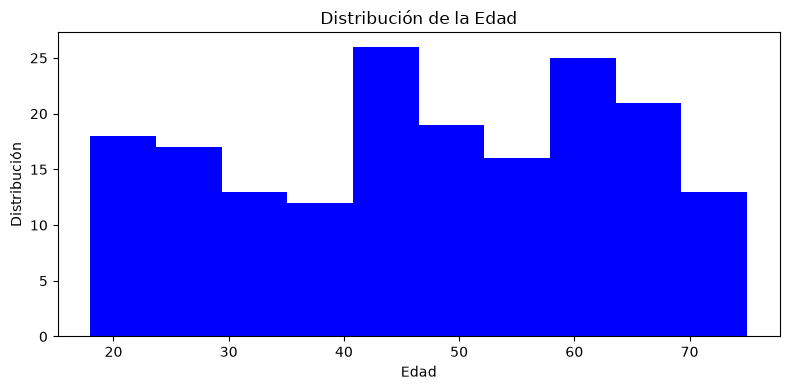

In [46]:
# TODO: crea el histograma de edad
plt.figure(figsize=(8, 4))
plt.hist(df['edad'], bins=10, color='blue')
plt.xlabel('Edad')
plt.ylabel('Distribución')
plt.title('Distribución de la Edad')
plt.tight_layout()
plt.show()

### Interpretación

**¿Qué información proporciona un histograma que no resulta tan fácil obtener observando directamente las filas del DataFrame?**

Un histograma muestra cómo se distribuyen los valores de una variable: dónde se concentran, qué intervalos son más o menos frecuentes, el rango y la forma general de la distribución. Esto permite detectar patrones, asimetrías o posibles valores atípicos que no son fáciles de apreciar mirando las filas individualmente.

### Ejercicio 17 - Abandono

Representa mediante un gráfico de barras el número de clientes que abandonaron y que no abandonaron.

Index(['No', 'Sí'], dtype='str', name='abandono')
[110  70]


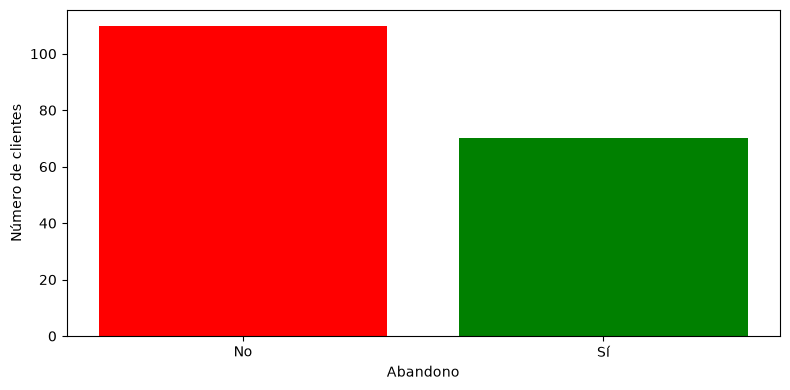

In [53]:
# TODO: crea el gráfico de barras
n_abandonos = df['abandono'].value_counts()
print(n_abandonos.index)
print(n_abandonos.values)
plt.figure(figsize=(8, 4))
plt.bar(n_abandonos.index, n_abandonos.values, color=['red', 'green'])
plt.xlabel('Abandono')
plt.ylabel('Número de clientes')
plt.tight_layout()
plt.show()

### Interpretación

Describe brevemente qué muestra el gráfico.

El gráfico muestra que la mayoría de los clientes **no abandonó**: aproximadamente 110 clientes, frente a unos 70 que sí abandonaron. Por tanto, hay más clientes que permanecen que clientes que se van.

### Ejercicio 18 - Cuota mensual

Crea un histograma para `cuota_mensual`.

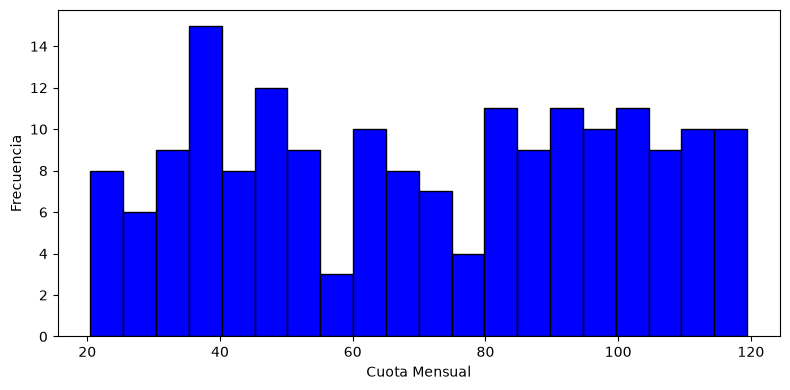

In [ ]:
# TODO: crea el histograma de cuota_mensual
plt.figure(figsize=(8, 4))
plt.hist(df['cuota_mensual'], bins=20, color='blue', edgecolor='black')
plt.xlabel('Cuota Mensual')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

### Interpretación

Analiza visualmente la distribución.

La cuota mensual presenta bastante variabilidad: los valores van aproximadamente de 20 a 120. Las frecuencias están repartidas a lo largo del rango, sin una concentración dominante; se observa un pico alrededor de 35–40 y menos clientes cerca de 55–60 y 75–80. En general, no parece haber una asimetría marcada.

### Ejercicio 19 - Edad y cuota

Crea un diagrama de dispersión utilizando:

\[
x = edad
\]

\[
y = cuota\_mensual
\]

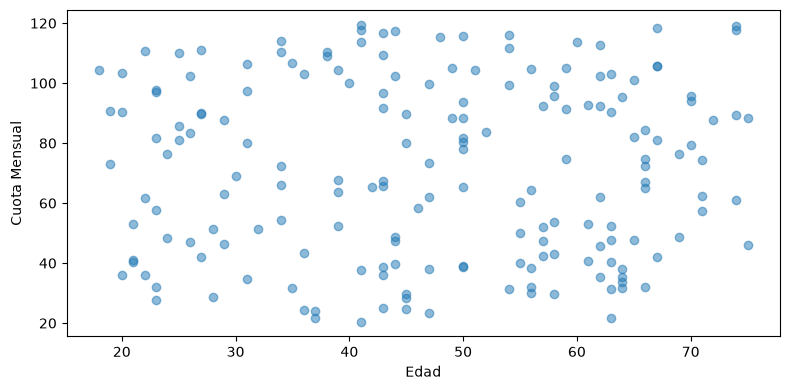

In [55]:
# TODO: crea el diagrama de dispersión
plt.figure(figsize=(8, 4))
plt.scatter(df['edad'], df['cuota_mensual'], alpha=0.5)
plt.xlabel('Edad')
plt.ylabel('Cuota Mensual')
plt.tight_layout()
plt.show()  

### Interpretación

- ¿Qué representa cada punto?
- ¿Observas a simple vista alguna relación clara entre ambas variables?

No es necesario realizar un análisis estadístico.

Escribe aquí tu respuesta.

Cada punto del gráfico representa una observación individual: un caso concreto en el que se han medido dos variables a la vez, una en el eje horizontal y otra en el eje vertical. Es decir, cada punto indica el valor de ambas variables para ese mismo elemento.

A simple vista, si los puntos se distribuyen siguiendo una tendencia clara (por ejemplo, creciendo de izquierda a derecha o decreciendo), entonces hay una relación entre las dos variables. Si, por el contrario, los puntos están muy dispersos y no forman un patrón definido, la relación no es clara o es débil.

En resumen: cada punto = un caso con dos medidas; la forma de la nube de puntos nos dice si ambas variables están relacionadas o no.

## Parte 9 - Identificación de $X$ e $y$

La empresa quiere construir en el futuro un modelo que determine si un cliente abandonará.

### Ejercicio 20 - Variable objetivo

Identifica y crea `y`. Después muestra sus cinco primeros valores.

In [58]:
# TODO: crea y
Y = df[['abandono']]


# TODO: muestra sus cinco primeros valores
Y.head()

,abandono
0,No
1,No
2,No
3,No
4,Sí


### Respuesta

**¿Por qué esta variable corresponde a \(y\)?**

Escribe aquí tu respuesta.
Porque en un diagrama de dispersión o relación entre dos variables, la variable y suele ser la variable dependiente, es decir, la que se observa como resultado o consecuencia de la otra.
'y' corresponde a la variable que se mide como efecto o resultado de 'x'.

### Ejercicio 21 - Características

Crea `X` utilizando inicialmente estas características:

- `edad`
- `antiguedad`
- `cuota_mensual`
- `consumo_datos`
- `llamadas_soporte`
- `incidencias`
- `tipo_contrato`
- `satisfaccion`

Después comprueba sus dimensiones.

In [57]:
# TODO: crea X
X = df[['edad', 'antiguedad', 'cuota_mensual', 'consumo_datos', 'incidencias', 'llamadas_soporte', 'tipo_contrato', 'satisfaccion']]


# TODO: muestra las dimensiones de X
print("Dimensiones de X:", X.shape)

Dimensiones de X: (180, 8)


### Respuesta

Si el dataset contiene \(n\) clientes, esperamos:

\[
X.shape = (n,\ ?)
\]

**¿Qué número debe aparecer en `?`? ¿Por qué?**

Debe aparecer el número de variables o características que se usan para describir a cada cliente.

Si hay n clientes y cada cliente tiene, por ejemplo, 2 variables (como edad y salario), entonces la matriz X tendría forma:

X.shape = (n, 2)

## Parte 10 - Razonamiento de Machine Learning

### Ejercicio 22 - Identificación del problema

Queremos predecir:

`abandono → Sí / No`

Responde razonadamente:

1. ¿Estamos ante aprendizaje supervisado o no supervisado?
2. ¿Por qué?
3. ¿Es clasificación o regresión?
4. ¿Por qué?
5. ¿Es clasificación binaria o multiclase?
6. ¿Cuáles son las clases?

### Respuesta

1. Aprendizaje supervisado.
2. Porque el modelo aprende con ejemplos que ya incluyen la respuesta correcta: si cada cliente abandonó o no.
3. Clasificación
4. Porque se predice una categoría, no un valor numérico.
5. Clasificación binaria, ya que hay dos resultados posibles.
5. Las clases son 'SI' (abandono) y 'No' (no abandono)

## Parte 11 - Un cambio en el problema

Supongamos ahora que la empresa plantea:

> Queremos predecir cuál será el **consumo de datos del próximo mes** de cada cliente.

### Ejercicio 23

Responde:

1. ¿Cuál sería ahora la variable objetivo?

    La variable objetivo sería el consumo de datos del próximo mes de cada cliente, es decir, una variable numérica que mide la cantidad de GB consumidos en el siguiente periodo.

2. ¿Seguiríamos teniendo exactamente el mismo X?

    No, no exactamente. Si queremos predecir el consumo futuro, no conviene incluir la propia variable `consumo_datos` como característica en `X`, porque sería la información que estamos intentando pronosticar. En general, podríamos mantener otras variables conocidas en el momento de la predicción, pero eliminando la variable objetivo o cualquier variable equivalente.

3. ¿Sería clasificación o regresión?

    Sería un problema de regresión, porque la salida que queremos predecir es un valor numérico continuo (cantidad de GB), no una categoría discreta como “Sí/No”.

4. ¿Seguiría siendo aprendizaje supervisado?

    Sí, seguiría siendo aprendizaje supervisado, porque contamos con datos históricos en los que cada cliente tiene un valor real de consumo de datos y el modelo puede aprender a relacionar ese valor con las características del cliente.

5. Justifica cada respuesta.

    - La variable objetivo cambia de `abandono` a `consumo_datos`, porque ahora lo que buscamos predecir es un número.
    - `X` no puede ser exactamente el mismo si la variable objetivo forma parte de las entradas; debe excluirse la información que se quiere predecir.
    - La regresión es la técnica adecuada cuando la salida es continua.
    - El aprendizaje supervisado requiere ejemplos con etiquetas o valores reales conocidos para entrenar el modelo.
4. ¿Seguiría siendo aprendizaje supervisado?

    Sí, seguiría siendo aprendizaje supervisado, porque disponemos de datos históricos en los que cada cliente tiene un valor real de consumo de datos y el modelo puede aprender la relación entre esas variables y la cantidad consumida.

5. Justifica cada respuesta.

    - La variable objetivo cambia de `abandono` a `consumo_datos`, porque ahora buscamos predecir un valor numérico y continuo: la cantidad de datos que consumirá cada cliente.
    - `X` no puede ser exactamente el mismo si la variable objetivo forma parte de las características, porque esa información sería precisamente lo que intentamos pronosticar. Lo adecuado es mantener otras variables conocidas y excluir la propia `consumo_datos`.
    - El problema sería de regresión, ya que la salida esperada es un número real, no una categoría.
    - Seguimos en aprendizaje supervisado porque contamos con ejemplos etiquetados con el valor real del consumo de datos, que permite entrenar al modelo.


## Parte 12 - Análisis crítico

### Ejercicio 24 - ¿Utilizarías `cliente_id`?

Los identificadores tienen valores como:

`10001, 10002, 10003, 10004, ...`

¿Utilizarías esta columna como característica para predecir el abandono?

No respondas únicamente «sí» o «no». Razona tu decisión.

### Respuesta

No utilizaría `cliente_id` como característica para predecir el abandono. Es un identificador que distingue a cada cliente, pero su valor numérico no expresa una propiedad del cliente ni una relación real con su abandono. Si se incluyera, el modelo podría aprender patrones accidentales de esos números y hacer predicciones poco fiables.

### Ejercicio 25 - ¿Estamos preparados para entrenar?

Después del análisis anterior, alguien propone ejecutar directamente:

```python
modelo.fit(X, y)
```

¿Estamos preparados?

Identifica **al menos cuatro cuestiones** que deberíamos estudiar o resolver antes de entrenar el modelo.

No necesitas explicar todavía cómo resolverlas.

### Respuesta

1. Definir correctamente 'X' e 'Y': y debe ser la columna objetivo (abandono) y X las variables predictoras, sin incluir identificadores como `cliente_id`.

2. Preparar los datos: comprobar si hay valores ausentes y tratar las variables categóricas para que el modelo pueda utilizarlas.

3. Evitar la fuga de información: asegurarnos de que ninguna característica revele directa o indirectamente el valor de abandono.

4. Separar los datos en conjuntos de entrenamiento y prueba para evaluar el modelo con datos que no haya visto.


## Parte 13 - Conclusiones

### Ejercicio 26 - Informe final

Escribe entre **8 y 12 líneas** resumiendo lo que has descubierto.

Debes incluir como mínimo:

- tamaño del dataset
- principales tipos de variables
- comportamiento de `abandono`
- alguna observación de las estadísticas
- alguna observación de las visualizaciones
- cuáles son \(X\) e \(y\)
- tipo de problema de Machine Learning
- qué pasos deberían realizarse antes de entrenar

### Conclusiones

El dataset contiene aproximadamente **180 clientes**.  
Incluye variables numéricas y categóricas para describir a cada cliente.  
La variable `abandono` indica si el cliente se fue («Sí») o permaneció («No»).  
En los datos hay más clientes que no abandonaron que clientes que sí lo hicieron.  
La cuota mensual varía aproximadamente entre 20 y 120, con valores repartidos en ese intervalo.  
Las visualizaciones ayudan a observar las frecuencias y la distribución de los valores.  
Para predecir el abandono, **X** serán las características de los clientes y **y** será `abandono`.  
Es un problema de aprendizaje supervisado de clasificación binaria, con clases «Sí» y «No».  
Antes de entrenar, hay que revisar valores ausentes, preparar las variables categóricas y excluir identificadores.  
También conviene separar los datos en conjuntos de entrenamiento y prueba y elegir métricas adecuadas.

---

# Ampliación opcional

Si terminas antes, investiga cómo obtener con pandas:

1. El número exacto de valores ausentes de cada columna.
2. El número de clientes agrupados por `tipo_contrato` y `abandono`.
3. La cuota mensual media de quienes abandonaron y de quienes no.
4. La satisfacción media de ambos grupos.

No utilices algoritmos de Machine Learning.

In [ ]:
# AMPLIACIÓN OPCIONAL

# 1. Valores ausentes por columna


# 2. Clientes agrupados por tipo_contrato y abandono


# 3. Cuota mensual media según abandono


# 4. Satisfacción media según abandono

# Antes de entregar

Comprueba que:

- has completado todas las celdas `TODO`
- has respondido las preguntas en Markdown
- todos los gráficos tienen título y etiquetas
- has reiniciado el entorno y ejecutado el notebook completo desde el principio
- no se producen errores
- no has entrenado ningún modelo

**Nombre recomendado del archivo de entrega:**

`Practica_03_Apellido_Nombre.ipynb`